In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image

In [5]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content.jpg
Saving style.jpg to style.jpg


In [6]:
def load_img(path):
    img = image.load_img(path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

content_image = load_img("content.jpg")
style_image = load_img("style.jpg")

In [7]:
vgg = VGG19(weights='imagenet', include_top=False)

for layer in vgg.layers:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
content_layer = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [9]:
outputs = [vgg.get_layer(name).output for name in (style_layers + content_layer)]

model = tf.keras.Model([vgg.input], outputs)

In [10]:
def content_loss(content, generated):
    return tf.reduce_mean(tf.square(content - generated))

In [11]:
def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.matmul(x, x, transpose_a=True)

def style_loss(style, generated):
    S = gram_matrix(style)
    G = gram_matrix(generated)
    return tf.reduce_mean(tf.square(S - G))

In [14]:
generated_image = tf.Variable(content_image, dtype=tf.float32)

optimizer = tf.optimizers.Adam(learning_rate=5.0)

In [16]:
for i in range(100):

    with tf.GradientTape() as tape:

        outputs = model(generated_image)

        style_outputs = outputs[:5]
        content_output = outputs[5]

        loss = 0

        # Style Loss
        for s in style_outputs:
            loss += tf.reduce_mean(tf.square(s))

        # Content Loss
        loss += content_loss(content_output, outputs[5])

    grad = tape.gradient(loss, generated_image)

    optimizer.apply_gradients([(grad, generated_image)])

    if i % 20 == 0:
        print("Iteration:", i, "Loss:", loss.numpy())

Iteration: 0 Loss: 1515503.2
Iteration: 20 Loss: 273519.2
Iteration: 40 Loss: 93374.82
Iteration: 60 Loss: 42895.945
Iteration: 80 Loss: 27478.957


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

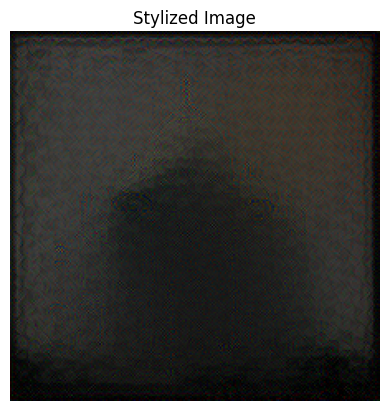

In [17]:
output = generated_image.numpy()[0]

plt.imshow(output/255)
plt.title("Stylized Image")
plt.axis("off")

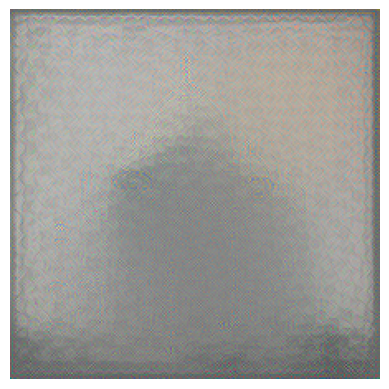

In [19]:
import numpy as np
import matplotlib.pyplot as plt

output = generated_image.numpy()[0]

output = (output - output.min()) / (output.max() - output.min())

plt.imshow(output)
plt.axis("off")

plt.imsave("stylized_output.png", output)

In [20]:
from google.colab import files
files.download("stylized_output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from google.colab import files
files.download("stylized_output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>